In [1]:
# BUSINESS SCIENCE -----
# LAB 91: CUSTOMER LIFETIME VALUE -----
# Part 2: PROBABILISTIC CLV MODELS (INTERMEDIATE) -----
# *** -----

# BUSINESS GOALS:
# 1. HOW MUCH CAN WE SPEND TO ACQUIRE A CUSTOMER? LIFETIME VALUE - COST TO ACQUIRE CUSTOMER (LTV - CAC)
# 2. WHICH CUSTOMERS ARE MOST VALUABLE? SEGMENTATION
# 3. HOW CAN WE INCREASE CUSTOMER LIFETIME VALUE? MARKETING STRATEGY

# 3 PARTS:
# 1. Descriptive CLV Models (covered in this script)
# 2. Probabilistic CLV Models (covered in Part 2)
# 3. Predictive CLV Models (covered in Part 3)
# * Stick around for Part 3, that's where we'll save the MOST MONEY!


In [2]:

# LIBRARIES -----
import pandas as pd
import pytimetk as tk
import lifetimes as lf
from lifetimes.plotting import plot_probability_alive_matrix


c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-15 16:46:52,055	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [7]:

# CONSTANTS -----
profit_margin = 0.15  # 15% Profit on Products

# DATA -----
transactions_df = pd.read_csv('data_transactions_processed.csv')

df = transactions_df.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.glimpse()


<class 'pandas.core.frame.DataFrame'>: 300000 rows of 23 columns
household_key:        int64             [103, 436, 349, 271, 107, 72, 18 ...
basket_id:            int64             [1537972, 1401354, 1293144, 1656 ...
day:                  int64             [78, 356, 121, 288, 649, 213, 64 ...
product_id:           int64             [549, 47, 468, 297, 514, 418, 36 ...
quantity:             int64             [6, 8, 1, 5, 4, 6, 8, 9, 9, 4, 1 ...
sales_value:          float64           [15.08, 17.13, 12.03, 7.73, 3.91 ...
store_id:             int64             [49, 36, 24, 6, 49, 29, 7, 20, 4 ...
retail_disc:          float64           [4.24, 0.84, 3.48, 2.12, 4.85, 2 ...
trans_time:           int64             [319, 411, 812, 113, 1051, 356,  ...
week_no:              int64             [12, 51, 18, 42, 93, 31, 92, 49, ...
coupon_disc:          float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0 ...
coupon_match_disc:    float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0 ...
commodity_d

In [8]:

# PROBABILISTIC MODELS -----
# - Probabilistic models are used to predict the future 
#   transactions and churn rate of a customer.

# Data Preparation -----
summary_3_df = lf.utils.summary_data_from_transaction_data(
    df,
    customer_id_col     = 'household_key',
    datetime_col        = 'timestamp',
    monetary_value_col  = 'sales_value',
)

# Will get an error in Gamma-Gamma model if there are non-positive values
summary_3_df[summary_3_df['monetary_value'] <= 0]

summary_3_df = summary_3_df[summary_3_df['monetary_value'] > 0]


In [11]:
summary_3_df.head()

,frequency,recency,T,monetary_value,probability_alive
household_key,,,,,
1,401.0,707.0,707.0,15.225686,1.0
2,423.0,709.0,709.0,14.100662,1.0
3,393.0,709.0,709.0,14.328906,1.0
4,399.0,710.0,710.0,15.356717,1.0
5,394.0,709.0,710.0,14.284289,1.0


In [9]:

# 1.0 BG/NBD model -----
# - The BG/NBD model is a probabilistic model that predicts the 
#   number of repeat purchases a customer will make.
# - BG/NBD model can only predict the future transactions and 
#   churn rate of a customer

# NOTE - If doesn't converge, increase penalizer_coef
bgf = lf.BetaGeoFitter(penalizer_coef=0.15)

bgf.fit(summary_3_df['frequency'], summary_3_df['recency'], summary_3_df['T'])

bgf.summary.round(2)


,coef,se(coef),lower 95% bound,upper 95% bound
r,1.36,0.06,1.25,1.47
alpha,2.39,0.13,2.12,2.65
a,0.00,0.00,-0.00,0.00
b,0.00,0.06,-0.11,0.11


In [10]:
# Conditional probability alive
summary_3_df['probability_alive'] = bgf.conditional_probability_alive(
    summary_3_df['frequency'], 
    summary_3_df['recency'], 
    summary_3_df['T']
)

summary_3_df


,frequency,recency,T,monetary_value,probability_alive
household_key,,,,,
1,401.0,707.0,707.0,15.225686,1.0
2,423.0,709.0,709.0,14.100662,1.0
3,393.0,709.0,709.0,14.328906,1.0
4,399.0,710.0,710.0,15.356717,1.0
5,394.0,709.0,710.0,14.284289,1.0
...,...,...,...,...,...
496,409.0,708.0,710.0,15.302005,1.0
497,389.0,710.0,710.0,15.958072,1.0
498,371.0,704.0,707.0,14.294070,1.0


<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

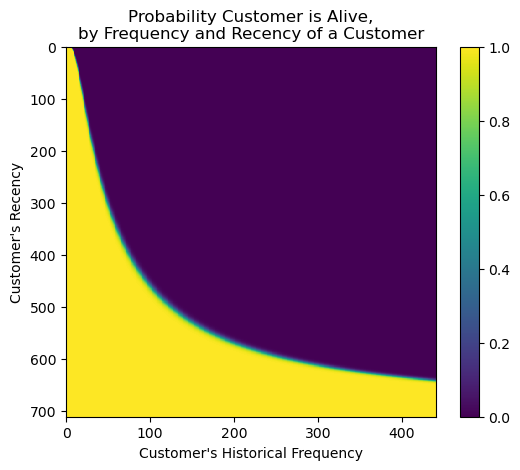

In [13]:

# Visualizing the probability alive matrix
plot_probability_alive_matrix(bgf, cmap='viridis')


In [14]:
# If a customer has bought multiple times (frequency) and the time
# between the first & last transaction is high (recency), then his/
# her probability of being alive is high.
# If a customer has less frequency (bought once or twice) and the
# time between first & last transaction is low (recency), then his/
# her probability of being alive is high.


In [15]:

# GAMMA-GAMMA MODEL -----
# - The Gamma-Gamma model is used to predict the average 
#   transaction value for each customer.

ggf = lf.GammaGammaFitter(penalizer_coef=0.1)

ggf.fit(summary_3_df['frequency'], summary_3_df['monetary_value'])

summary_3_df['predicted_avg_sales'] = ggf.conditional_expected_average_profit(
    summary_3_df['frequency'],
    summary_3_df['monetary_value']
)

summary_3_df


,frequency,recency,T,monetary_value,probability_alive,predicted_avg_sales
household_key,,,,,,
1,401.0,707.0,707.0,15.225686,1.0,15.245384
2,423.0,709.0,709.0,14.100662,1.0,14.118179
3,393.0,709.0,709.0,14.328906,1.0,14.348014
4,399.0,710.0,710.0,15.356717,1.0,15.376656
5,394.0,709.0,710.0,14.284289,1.0,14.303300
...,...,...,...,...,...,...
496,409.0,708.0,710.0,15.302005,1.0,15.321398
497,389.0,710.0,710.0,15.958072,1.0,15.979196
498,371.0,704.0,707.0,14.294070,1.0,14.314272


In [17]:

# Predict the Customer Lifetime Value for Next 90 Days -----

summary_3_df['predicted_clv_3mo'] = ggf.customer_lifetime_value(
    bgf,
    summary_3_df['frequency'],
    summary_3_df['recency'],
    summary_3_df['T'],
    summary_3_df['monetary_value'],
    time=3,   # Time in Months
    freq='D', # Daily
    discount_rate=0.01 # 1% discount rate
)

summary_3_df

,frequency,recency,T,monetary_value,probability_alive,predicted_avg_sales,predicted_clv_3mo
household_key,,,,,,,
1,401.0,707.0,707.0,15.225686,1.0,15.245384,762.931714
2,423.0,709.0,709.0,14.100662,1.0,14.118179,743.058251
3,393.0,709.0,709.0,14.328906,1.0,14.348014,701.769515
4,399.0,710.0,710.0,15.356717,1.0,15.376656,762.451708
5,394.0,709.0,710.0,14.284289,1.0,14.303300,700.371962
...,...,...,...,...,...,...,...
496,409.0,708.0,710.0,15.302005,1.0,15.321398,778.687381
497,389.0,710.0,710.0,15.958072,1.0,15.979196,772.538318
498,371.0,704.0,707.0,14.294070,1.0,14.314272,662.925813


In [ ]:
# Don't forget to add in profit margin
summary_3_df['predicted_profit_3mo'] = summary_3_df['predicted_clv_3mo'] * profit_margin

summary_3_df

,frequency,recency,T,monetary_value,probability_alive,predicted_avg_sales,predicted_clv_3mo,predicted_profit_3mo
household_key,,,,,,,,
1,401.0,707.0,707.0,15.225686,1.0,15.245384,762.931714,114.439757
2,423.0,709.0,709.0,14.100662,1.0,14.118179,743.058251,111.458738
3,393.0,709.0,709.0,14.328906,1.0,14.348014,701.769515,105.265427
4,399.0,710.0,710.0,15.356717,1.0,15.376656,762.451708,114.367756
5,394.0,709.0,710.0,14.284289,1.0,14.303300,700.371962,105.055794
...,...,...,...,...,...,...,...,...
496,409.0,708.0,710.0,15.302005,1.0,15.321398,778.687381,116.803107
497,389.0,710.0,710.0,15.958072,1.0,15.979196,772.538318,115.880748
498,371.0,704.0,707.0,14.294070,1.0,14.314272,662.925813,99.438872


In [25]:
# CONCLUSIONS -----
# 1. Now we know how much we can spend to target these customers 
#    in the next 3 months.
# 2. Much better than the historical / descriptive models as it 
#    predicts the future transactions and churn rate of a customer.
# 3. However, we don't know what relationships exist between the 
#    features and the lifetime value of a customer, and therefore, 
#    we can't confidently improve the business.
# 4. The next step is to build predictive models to forecast 
#    future customer lifetime value AND to understand the relationships 
#    between the features and the lifetime value of a customer.

In [27]:
# Notes, this study is based on a false premiss, a store isn't generally taking 15% profit margin
# on all of its products, so we should instead use a net_profit per transaction and 
# replace the monetary column with that, and use gamma-gamma to then come up with the predictions 
# for the expected net profit per customer over the time horizon provided.